# Ablative Study - EfficientNet B2
Brain MRI classification trained on 3 datasets using EfficientNet-B2 (untrained weights).

## 1. Setup

In [1]:
#Install Dependencies
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 --upgrade --quiet
!pip install numpy pandas matplotlib seaborn scikit-learn torchmetrics grad-cam --quiet

In [2]:
import copy, time, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchmetrics import Accuracy, Precision, Recall, F1Score
from sklearn.metrics import classification_report, confusion_matrix
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

try:
    from google.colab import drive
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Device setup
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    torch.backends.cudnn.benchmark = True   # optimise conv for fixed input sizes
    torch.backends.cudnn.deterministic = False  # faster, fine for training
    gpu = torch.cuda.get_device_properties(0)
    print(f'Using GPU : {gpu.name}  ({gpu.total_memory / 1024**3:.1f} GB VRAM)')
else:
    DEVICE = torch.device('cpu')
    print('No CUDA GPU found — running on CPU')

print(f'PyTorch   : {torch.__version__}')
print(f'CUDA      : {torch.version.cuda}')
print(f'Running on: {"Google Colab" if ON_COLAB else "local environment"}')

Using GPU : NVIDIA GeForce RTX 4050 Laptop GPU  (6.0 GB VRAM)
PyTorch   : 2.10.0+cu126
CUDA      : 12.6
Running on: local environment


In [3]:
if ON_COLAB:
    drive.mount('/content/drive')
    OUTPUT_DIR = Path('/content/drive/MyDrive/COMP472/outputs/efficientnet_b2')
    preprocessed_dir = '/content/drive/MyDrive/brain_mri_preprocessed'
else:
    #  Local paths 
    OUTPUT_DIR       = Path('./outputs/efficientnet_b2')
    preprocessed_dir = './brain_mri_preprocessed'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output directory : {OUTPUT_DIR}')
print(f'Preprocessed data: {preprocessed_dir}')

Output directory : outputs\efficientnet_b2
Preprocessed data: ./brain_mri_preprocessed


## 2.Ablative Study Setups


In [4]:
#Default , Base parameters
BATCH_SIZE    = 32
NUM_EPOCHS    = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4
IMG_SIZE      = 224

In [5]:
# Experiment configurations for ablation study on Dataset 2
experiments = [
    {
        "name": "full_dataset",
        "classes": ["glioma", "meningioma", "notumor", "pituitary"],
        "images_per_class": None,
        "learning_rate": 0.001,
        "batch_size": 32
    },
    {
        "name": "reduced_classes",
        "classes": ["glioma", "meningioma", "pituitary"],
        "images_per_class": None,
        "learning_rate": 0.001,
        "batch_size": 32
    },
    {
        "name": "limited_images",
        "classes": ["glioma", "meningioma", "notumor", "pituitary"],
        "images_per_class": 50,
        "learning_rate": 0.001,
        "batch_size": 32
    },
    {
        "name": "very_limited_images",
        "classes": ["glioma", "meningioma", "notumor", "pituitary"],
        "images_per_class": 25,
        "learning_rate": 0.001,
        "batch_size": 32
    },
    {
        "name": "learning_rate_x10",
        "classes": ["glioma", "meningioma", "notumor", "pituitary"],
        "images_per_class": None,
        "learning_rate": 0.010,
        "batch_size": 32
    },
    {
        "name": "learning_rate_div2",
        "classes": ["glioma", "meningioma", "notumor", "pituitary"],
        "images_per_class": None,
        "learning_rate": 0.0005,
        "batch_size": 32
    },
    {
        "name": "batch_size_100",
        "classes": ["glioma", "meningioma", "notumor", "pituitary"],
        "images_per_class": None,
        "learning_rate": 0.001,
        "batch_size": 100
    },
    {
        "name": "batch_size_15",
        "classes": ["glioma", "meningioma", "notumor", "pituitary"],
        "images_per_class": None,
        "learning_rate": 0.001,
        "batch_size": 15
    },
]

print(f'{len(experiments)} experiments defined')
for exp in experiments:
    print(f'  {exp["name"]:<30} classes={len(exp["classes"])}  img/cls={exp["images_per_class"] or "all":>4}  lr={exp["learning_rate"]}  bs={exp["batch_size"]}')

8 experiments defined
  full_dataset                   classes=4  img/cls= all  lr=0.001  bs=32
  reduced_classes                classes=3  img/cls= all  lr=0.001  bs=32
  limited_images                 classes=4  img/cls=  50  lr=0.001  bs=32
  very_limited_images            classes=4  img/cls=  25  lr=0.001  bs=32
  learning_rate_x10              classes=4  img/cls= all  lr=0.01  bs=32
  learning_rate_div2             classes=4  img/cls= all  lr=0.0005  bs=32
  batch_size_100                 classes=4  img/cls= all  lr=0.001  bs=100
  batch_size_15                  classes=4  img/cls= all  lr=0.001  bs=15


## 3. Data

Images have been preprocessed to grayscale, tensors of 224×224 and normalized 0–255 → [0, 1].

### 3.1 Load Datasets

In [6]:
from torch.utils.data import DataLoader

# Dataset 2 : 7,023 images — 4 classes
train_data_ds2 = torch.load(f'{preprocessed_dir}/dataset2_train.pt')
val_data_ds2   = torch.load(f'{preprocessed_dir}/dataset2_val.pt')
test_data_ds2  = torch.load(f'{preprocessed_dir}/dataset2_test.pt')

train_images_ds2   = train_data_ds2['images']
train_labels_ds2   = train_data_ds2['labels']
val_images_ds2     = val_data_ds2['images']
val_labels_ds2     = val_data_ds2['labels']
test_images_ds2    = test_data_ds2['images']
test_labels_ds2    = test_data_ds2['labels']
class_to_label_ds2 = train_data_ds2['class_to_label']   # e.g. {'glioma':0, 'meningioma':1, ...}

print(f'Dataset 2 loaded — class_to_label: {class_to_label_ds2}')
print(f'  Train: {len(train_images_ds2):,}  Val: {len(val_images_ds2):,}  Test: {len(test_images_ds2):,}')

Dataset 2 loaded — class_to_label: {'glioma': 0, 'meningioma': 1, 'pituitary': 2, 'notumor': 3}
  Train: 4,900  Val: 700  Test: 1,600


### 3.2 Data Augmentation

MONAI transforms are applied on-the-fly during training only.

In [7]:
!pip install monai --quiet

In [8]:
import logging, os, sys, tempfile
from monai.transforms import (
    Compose,
    RandRotate,
    RandZoom,
    RandGaussianNoise,
    RandAdjustContrast,
    RandShiftIntensity,
)


class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


def get_train_transforms():
    return Compose([
        RandRotate(range_x=0.15, prob=0.5, keep_size=True),
        RandZoom(min_zoom=0.95, max_zoom=1.05, prob=0.3, keep_size=True),
        RandGaussianNoise(mean=0.0, std=0.01, prob=0.2),
        RandAdjustContrast(gamma=(0.9, 1.1), prob=0.2),
        RandShiftIntensity(offsets=0.05, prob=0.2),
    ])

print('AugmentedDataset and transforms ready')

AugmentedDataset and transforms ready


### 3.3 DataLoaders

In [9]:
def build_exp_loaders(exp):
    """Filter Dataset 2 tensors for this experiment and return DataLoaders."""
    keep_classes     = exp['classes']
    images_per_class = exp['images_per_class']
    batch_size       = exp['batch_size']

    # Map each kept class name → its original label int, then remap to 0..N-1
    keep_label_ints = [class_to_label_ds2[c] for c in keep_classes]
    new_label_map   = {old: new for new, old in enumerate(keep_label_ints)}
    label_tensor    = torch.tensor(keep_label_ints)

    def filter_split(images, labels, limit_train=False):
        mask   = torch.isin(labels, label_tensor)
        imgs_f = images[mask]
        lbls_f = torch.tensor([new_label_map[l.item()] for l in labels[mask]], dtype=torch.long)

        if limit_train and images_per_class is not None:
            kept = []
            g    = torch.Generator(); g.manual_seed(SEED)
            for new_lbl in range(len(keep_classes)):
                idx = (lbls_f == new_lbl).nonzero(as_tuple=True)[0]
                idx = idx[torch.randperm(len(idx), generator=g)][:images_per_class]
                kept.append(idx)
            kept   = torch.cat(kept)
            imgs_f = imgs_f[kept]
            lbls_f = lbls_f[kept]

        return imgs_f, lbls_f

    tr_img, tr_lbl = filter_split(train_images_ds2, train_labels_ds2, limit_train=True)
    va_img, va_lbl = filter_split(val_images_ds2,   val_labels_ds2)
    te_img, te_lbl = filter_split(test_images_ds2,  test_labels_ds2)

    train_ds = AugmentedDataset(tr_img, tr_lbl, transform=get_train_transforms())
    val_ds   = AugmentedDataset(va_img, va_lbl, transform=None)
    test_ds  = AugmentedDataset(te_img, te_lbl, transform=None)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)

    print(f'  Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}  Classes: {keep_classes}')
    return train_loader, val_loader, test_loader, keep_classes

print('build_exp_loaders ready')

build_exp_loaders ready


## 4. Model — EfficientNet B2

- Input channel modified: 3 to 1 (grayscale MRI)
- Classifier head replaced to match `num_classes` (4 or 44)
- Weights: random init (no pretrained weights)

In [10]:
def build_efficientNet_b2(num_classes: int) -> nn.Module:
    model = models.efficientnet_b2(weights=None)
    # Replace first conv to accept 1-channel (grayscale) input
    model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
    # Replace classifier head
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model.to(DEVICE)


# Sanity check
_m = build_efficientNet_b2(4)
_x = torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
print(f'Output shape    : {list(_m(_x).shape)}')
print(f'Trainable params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
print(_m.features[0][0])
del _m, _x

Output shape    : [2, 4]
Trainable params: 7,706,054
Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)


## 5. Training & Evaluation Functions

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, num_classes):
    model.train()
    loss_sum = 0.0
    acc_m = Accuracy(task='multiclass', num_classes=num_classes).to(DEVICE)
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        acc_m.update(out.argmax(1), labels)
    return loss_sum / len(loader.dataset), acc_m.compute().item()


@torch.no_grad()
def evaluate(model, loader, criterion, num_classes):
    model.eval()
    loss_sum = 0.0
    acc_m = Accuracy(task='multiclass', num_classes=num_classes).to(DEVICE)
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = model(imgs)
        loss_sum += criterion(out, labels).item() * imgs.size(0)
        acc_m.update(out.argmax(1), labels)
    return loss_sum / len(loader.dataset), acc_m.compute().item()


@torch.no_grad()
def full_evaluation(model, loader, num_classes, class_names):
    model.eval()
    all_preds, all_labels = [], []
    ms = {
        'acc':  Accuracy( task='multiclass', num_classes=num_classes, average='macro').to(DEVICE),
        'prec': Precision(task='multiclass', num_classes=num_classes, average='macro').to(DEVICE),
        'rec':  Recall(   task='multiclass', num_classes=num_classes, average='macro').to(DEVICE),
        'f1':   F1Score(  task='multiclass', num_classes=num_classes, average='macro').to(DEVICE),
    }
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs).argmax(1)
        for m in ms.values(): m.update(preds, labels)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    results = {k: v.compute().item() for k, v in ms.items()}
    results.update({'all_preds': all_preds, 'all_labels': all_labels})

    print(f"  Accuracy : {results['acc']:.4f}")
    print(f"  Precision: {results['prec']:.4f}")
    print(f"  Recall   : {results['rec']:.4f}")
    print(f"  F1-Score : {results['f1']:.4f}")
    print(classification_report(all_labels, all_preds,
          target_names=(class_names if len(class_names) <= 20 else None), digits=4))
    return results


def train_model(model, cfg, save_path, learning_rate=LEARNING_RATE):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val, best_w = float('inf'), None
    nc = cfg['num_classes']

    for ep in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tl, ta = train_one_epoch(model, cfg['train_loader'], criterion, optimizer, nc)
        vl, va = evaluate(model, cfg['val_loader'], criterion, nc)
        scheduler.step(vl)
        for k, v in zip(history, [tl, vl, ta, va]): history[k].append(v)
        flag = ''
        if vl < best_val:
            best_val, best_w = vl, copy.deepcopy(model.state_dict())
            torch.save(best_w, save_path)
            flag = ' ✅'
        print(f'Ep [{ep:>2}/{NUM_EPOCHS}] Train {tl:.4f}/{ta:.4f} | Val {vl:.4f}/{va:.4f} | {time.time()-t0:.1f}s{flag}')

    model.load_state_dict(best_w)
    return model, history


print('Training & evaluation functions ready')

Training & evaluation functions ready


## 6. Visualization Functions

In [12]:
def plot_curves(history, name, save_path):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'EfficientNet B2 — {name}', fontweight='bold')
    for ax, key, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
        ax.plot(epochs, history[f'train_{key}'], 'b-o', ms=4, label='Train')
        ax.plot(epochs, history[f'val_{key}'],   'r-o', ms=4, label='Val')
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)
        if key == 'acc': ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()


def plot_confusion_matrix(results, class_names, name, save_path):
    cm = confusion_matrix(results['all_labels'], results['all_preds'], normalize='true')
    n  = len(class_names)
    fig, ax = plt.subplots(figsize=(min(n*0.7+2, 20), min(n*0.6+2, 18)))
    sns.heatmap(cm, annot=(n <= 15), fmt=('.2f' if n <= 15 else ''), cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.xticks(rotation=45, ha='right', fontsize=(8 if n > 15 else 10))
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()


def plot_grad_cam(model, loader, class_names, name, save_path, n=8):
    model.eval()
    cam = GradCAM(model=model, target_layers=[model.features[-1]])
    imgs, labels = next(iter(loader))
    imgs = imgs[:n].to(DEVICE)
    with torch.no_grad():
        preds = model(imgs).argmax(1).cpu()
    mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
    fig, axes = plt.subplots(2, n // 2, figsize=(n * 2, 8))
    fig.suptitle(f'Grad-CAM — {name}', fontweight='bold')
    for i, ax in enumerate(axes.flatten()):
        gc = cam(input_tensor=imgs[i:i+1], targets=[ClassifierOutputTarget(preds[i].item())])[0]
        img_np = np.clip(std * imgs[i].cpu().numpy().transpose(1, 2, 0) + mean, 0, 1).astype(np.float32)
        ax.imshow(show_cam_on_image(img_np, gc, use_rgb=True))
        ax.set_title(f'True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}',
                     color=('green' if preds[i] == labels[i] else 'red'), fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()


print('Visualization functions ready')

Visualization functions ready


## 7. Train on Dataset 2 - for each experiment


  Experiment : full_dataset
  Classes    : ['glioma', 'meningioma', 'notumor', 'pituitary']  (4)
  Img/class  : all
  LR         : 0.001   Batch: 32
  Train: 4,900  Val: 700  Test: 1,600  Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Ep [ 1/20] Train 0.9946/0.5894 | Val 1.2339/0.5771 | 621.4s ✅
Ep [ 2/20] Train 0.7374/0.7202 | Val 0.6782/0.7757 | 565.8s ✅
Ep [ 3/20] Train 0.5713/0.7959 | Val 0.4606/0.8557 | 478.9s ✅
Ep [ 4/20] Train 0.4682/0.8243 | Val 0.3683/0.8814 | 543.2s ✅
Ep [ 5/20] Train 0.4259/0.8447 | Val 0.3828/0.8429 | 534.3s
Ep [ 6/20] Train 0.3705/0.8655 | Val 0.4545/0.8357 | 535.1s
Ep [ 7/20] Train 0.3055/0.8892 | Val 0.3024/0.9029 | 990.5s ✅
Ep [ 8/20] Train 0.2871/0.8986 | Val 0.2359/0.9057 | 527.9s ✅
Ep [ 9/20] Train 0.2585/0.9078 | Val 0.2304/0.9257 | 521.9s ✅
Ep [10/20] Train 0.2916/0.8990 | Val 0.2910/0.8986 | 532.2s
Ep [11/20] Train 0.2054/0.9237 | Val 0.2461/0.9143 | 530.4s
Ep [12/20] Train 0.2036/0.9286 | Val 0.2068/0.9257 | 529.8s ✅
Ep [13/20] Train 

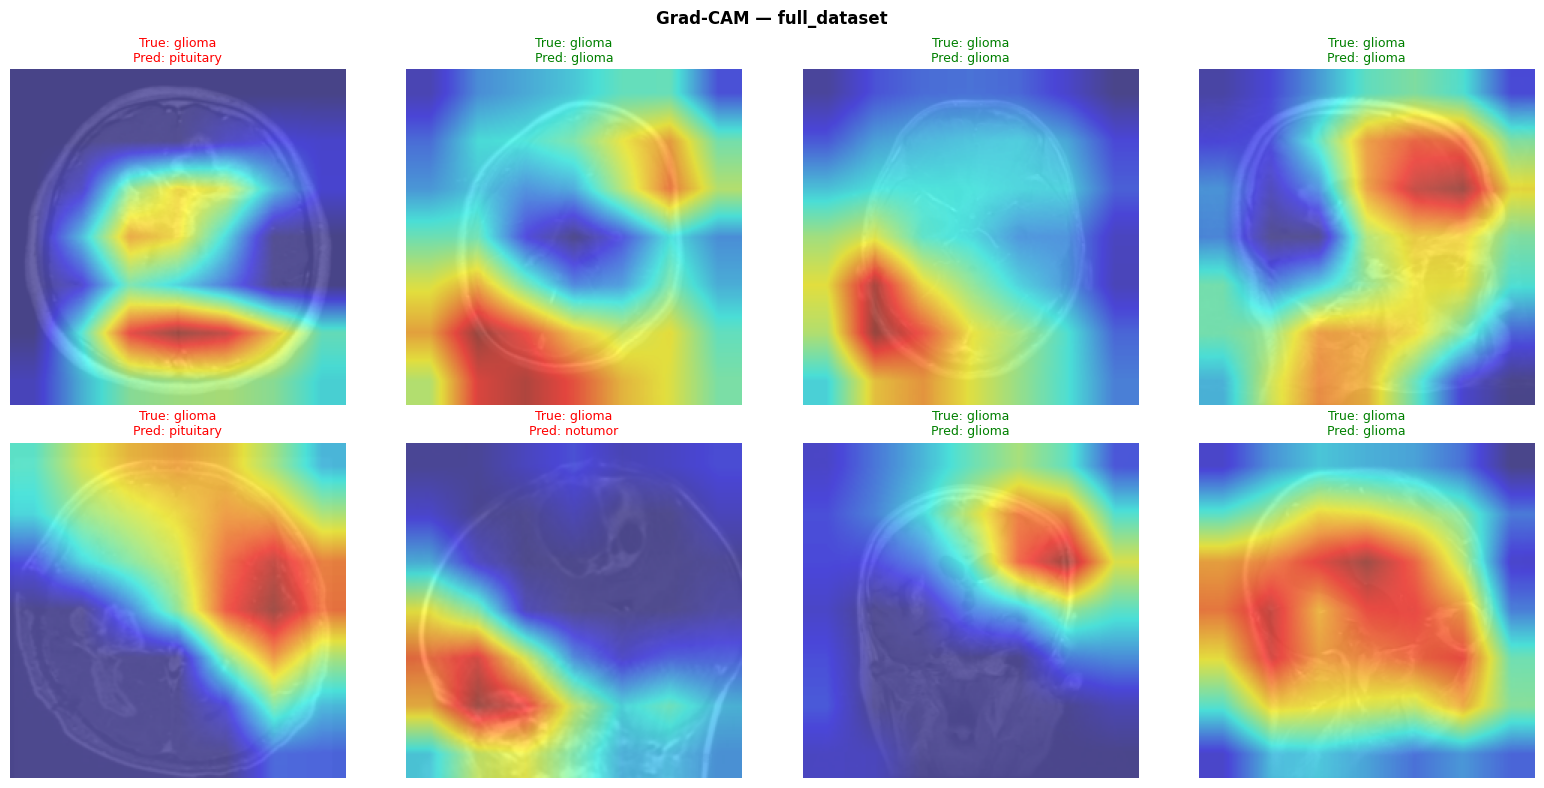


  Experiment : reduced_classes
  Classes    : ['glioma', 'meningioma', 'pituitary']  (3)
  Img/class  : all
  LR         : 0.001   Batch: 32
  Train: 3,675  Val: 525  Test: 1,200  Classes: ['glioma', 'meningioma', 'pituitary']
Ep [ 1/20] Train 0.9411/0.5510 | Val 0.7934/0.5905 | 190.4s ✅
Ep [ 2/20] Train 0.6584/0.7309 | Val 0.5423/0.7829 | 146.9s ✅
Ep [ 3/20] Train 0.5214/0.8022 | Val 0.6424/0.7562 | 148.7s
Ep [ 4/20] Train 0.4462/0.8269 | Val 4.2343/0.3848 | 154.3s
Ep [ 5/20] Train 0.3747/0.8561 | Val 0.4577/0.8343 | 151.8s ✅
Ep [ 6/20] Train 0.4172/0.8359 | Val 0.3866/0.8571 | 150.3s ✅
Ep [ 7/20] Train 0.3704/0.8561 | Val 0.3689/0.8648 | 148.4s ✅
Ep [ 8/20] Train 0.3048/0.8849 | Val 0.2530/0.8990 | 152.8s ✅
Ep [ 9/20] Train 0.2598/0.9037 | Val 0.8960/0.7467 | 152.0s
Ep [10/20] Train 0.2405/0.9127 | Val 0.2128/0.9238 | 151.1s ✅
Ep [11/20] Train 0.2345/0.9116 | Val 0.2087/0.9200 | 153.9s ✅
Ep [12/20] Train 0.2120/0.9159 | Val 0.2466/0.9200 | 149.1s
Ep [13/20] Train 0.1925/0.9244 | Val

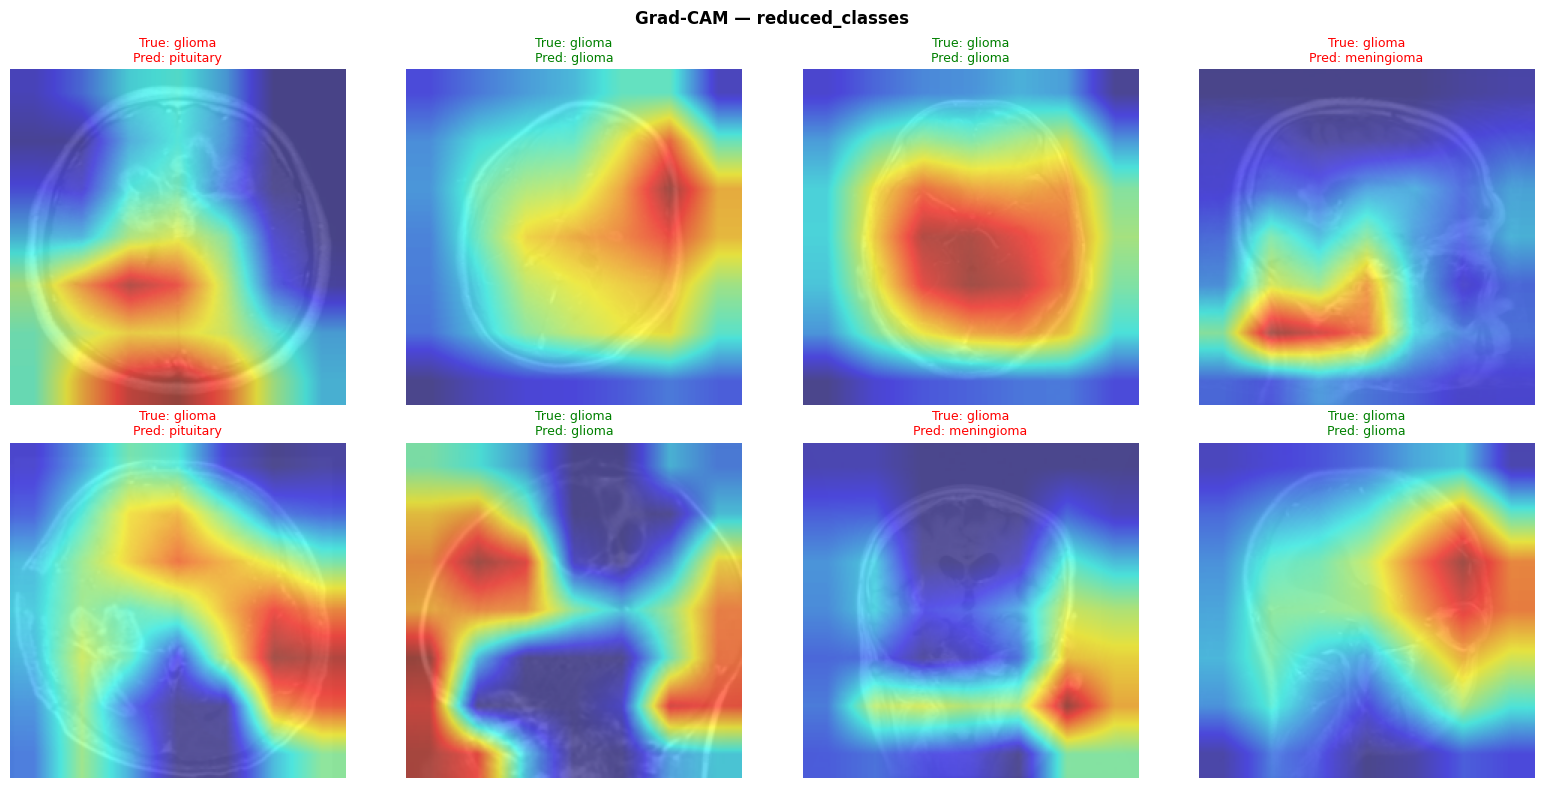


  Experiment : limited_images
  Classes    : ['glioma', 'meningioma', 'notumor', 'pituitary']  (4)
  Img/class  : 50
  LR         : 0.001   Batch: 32
  Train: 200  Val: 700  Test: 1,600  Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Ep [ 1/20] Train 1.2589/0.3800 | Val 1.4216/0.2500 | 9.4s ✅
Ep [ 2/20] Train 1.2493/0.3950 | Val 1.4355/0.2500 | 8.1s
Ep [ 3/20] Train 1.2262/0.4150 | Val 1.4224/0.2500 | 8.1s
Ep [ 4/20] Train 1.1112/0.4600 | Val 1.4396/0.2500 | 8.1s
Ep [ 5/20] Train 1.0623/0.5900 | Val 1.4343/0.2500 | 8.1s
Ep [ 6/20] Train 0.9519/0.6250 | Val 1.4812/0.2500 | 8.1s
Ep [ 7/20] Train 0.8669/0.6600 | Val 1.5114/0.2500 | 8.1s
Ep [ 8/20] Train 0.8816/0.6200 | Val 1.6277/0.2500 | 8.1s
Ep [ 9/20] Train 0.8001/0.6300 | Val 1.9150/0.2500 | 7.9s
Ep [10/20] Train 0.9127/0.6850 | Val 1.8673/0.2700 | 8.1s
Ep [11/20] Train 0.8186/0.6200 | Val 1.5237/0.3429 | 8.2s
Ep [12/20] Train 0.7794/0.7000 | Val 1.1540/0.5200 | 8.3s ✅
Ep [13/20] Train 0.7304/0.7250 | Val 0.8279/0.6686 | 7

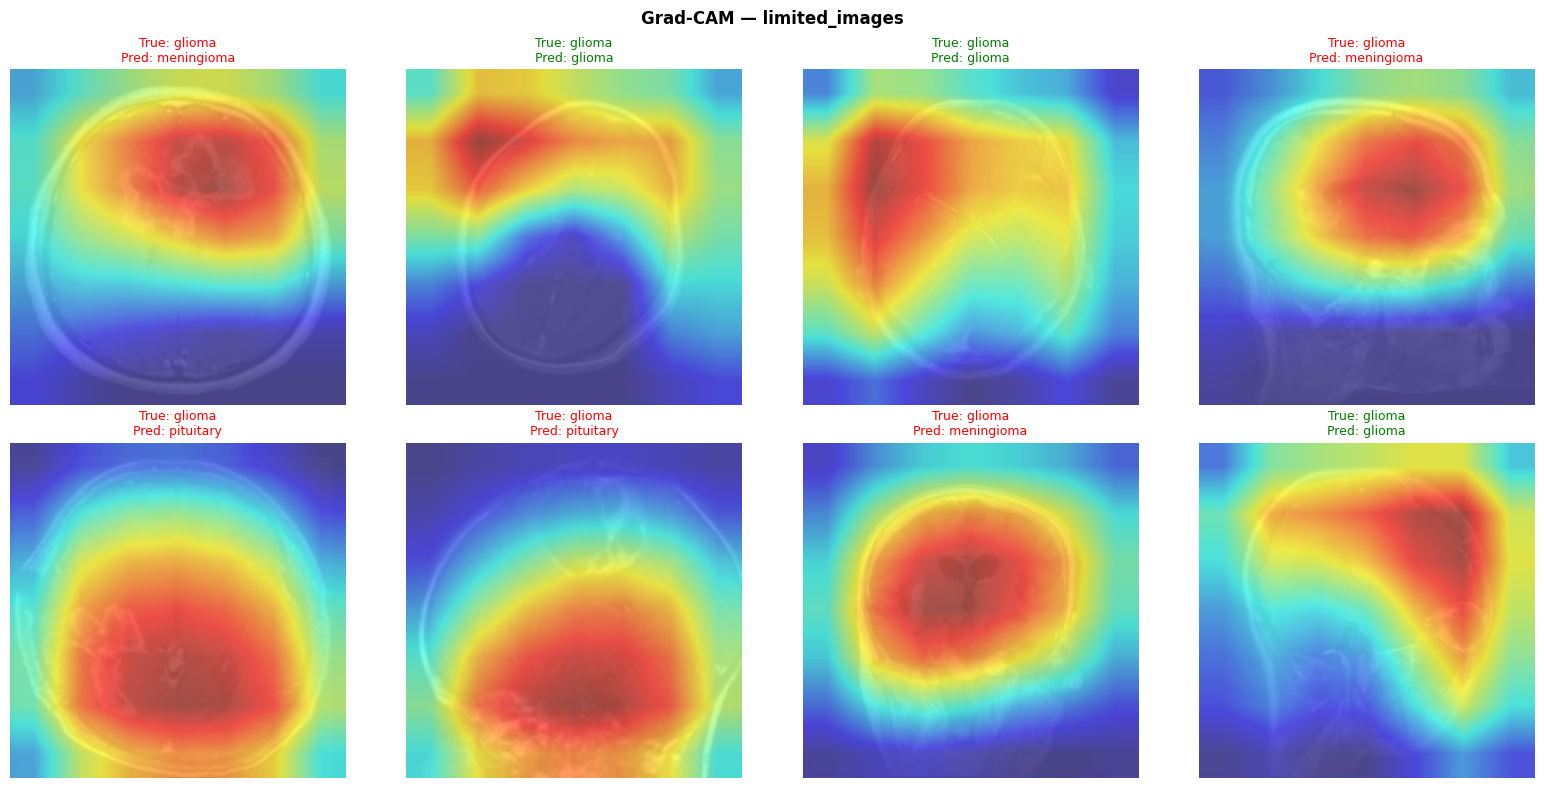


  Experiment : very_limited_images
  Classes    : ['glioma', 'meningioma', 'notumor', 'pituitary']  (4)
  Img/class  : 25
  LR         : 0.001   Batch: 32
  Train: 100  Val: 700  Test: 1,600  Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Ep [ 1/20] Train 1.3460/0.3400 | Val 1.4077/0.2500 | 3.8s ✅
Ep [ 2/20] Train 1.2850/0.3400 | Val 1.4489/0.2500 | 3.9s
Ep [ 3/20] Train 1.2579/0.3800 | Val 1.4828/0.2500 | 3.8s
Ep [ 4/20] Train 1.2100/0.4200 | Val 1.4724/0.2500 | 3.7s
Ep [ 5/20] Train 1.1658/0.4400 | Val 1.4309/0.2500 | 3.8s
Ep [ 6/20] Train 1.1929/0.3900 | Val 1.4344/0.2500 | 3.7s
Ep [ 7/20] Train 1.0828/0.5500 | Val 1.4519/0.2500 | 3.7s
Ep [ 8/20] Train 1.0254/0.5200 | Val 1.4611/0.2500 | 3.7s
Ep [ 9/20] Train 1.0725/0.5200 | Val 1.4796/0.2500 | 3.7s
Ep [10/20] Train 0.9077/0.6300 | Val 1.4816/0.2500 | 3.8s
Ep [11/20] Train 0.8908/0.6100 | Val 1.4896/0.2500 | 3.7s
Ep [12/20] Train 0.9530/0.6000 | Val 1.5038/0.2500 | 3.7s
Ep [13/20] Train 0.8723/0.6100 | Val 1.5199/0.2500 

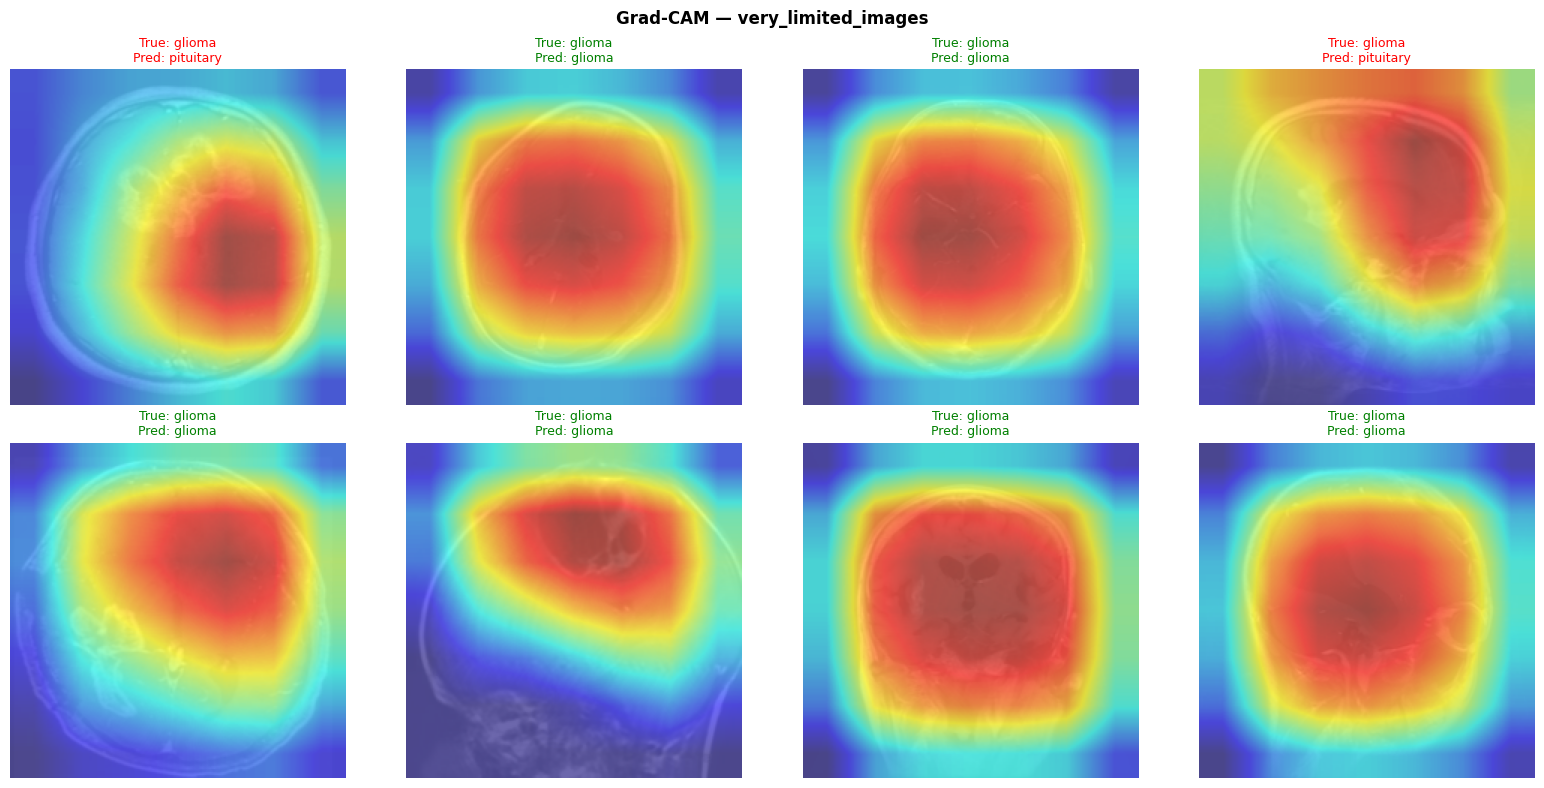


  Experiment : learning_rate_x10
  Classes    : ['glioma', 'meningioma', 'notumor', 'pituitary']  (4)
  Img/class  : all
  LR         : 0.01   Batch: 32
  Train: 4,900  Val: 700  Test: 1,600  Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Ep [ 1/20] Train 1.3797/0.3837 | Val 1.0933/0.4543 | 197.9s ✅
Ep [ 2/20] Train 0.9820/0.5835 | Val 0.9816/0.5743 | 220.6s ✅
Ep [ 3/20] Train 0.7878/0.6853 | Val 0.7646/0.6900 | 206.1s ✅
Ep [ 4/20] Train 0.6991/0.7392 | Val 0.9647/0.5457 | 211.3s
Ep [ 5/20] Train 0.6633/0.7514 | Val 0.6219/0.7500 | 210.7s ✅
Ep [ 6/20] Train 0.5655/0.7939 | Val 0.7895/0.6671 | 207.7s
Ep [ 7/20] Train 0.5336/0.8080 | Val 0.9449/0.7000 | 205.9s
Ep [ 8/20] Train 0.4754/0.8322 | Val 0.3930/0.8529 | 211.2s ✅
Ep [ 9/20] Train 0.4352/0.8471 | Val 0.4409/0.8300 | 222.1s
Ep [10/20] Train 0.4083/0.8520 | Val 0.3340/0.8614 | 230.0s ✅
Ep [11/20] Train 0.3813/0.8616 | Val 0.6583/0.7729 | 226.4s
Ep [12/20] Train 0.3914/0.8580 | Val 0.6325/0.8243 | 223.0s
Ep [13/20] Train 

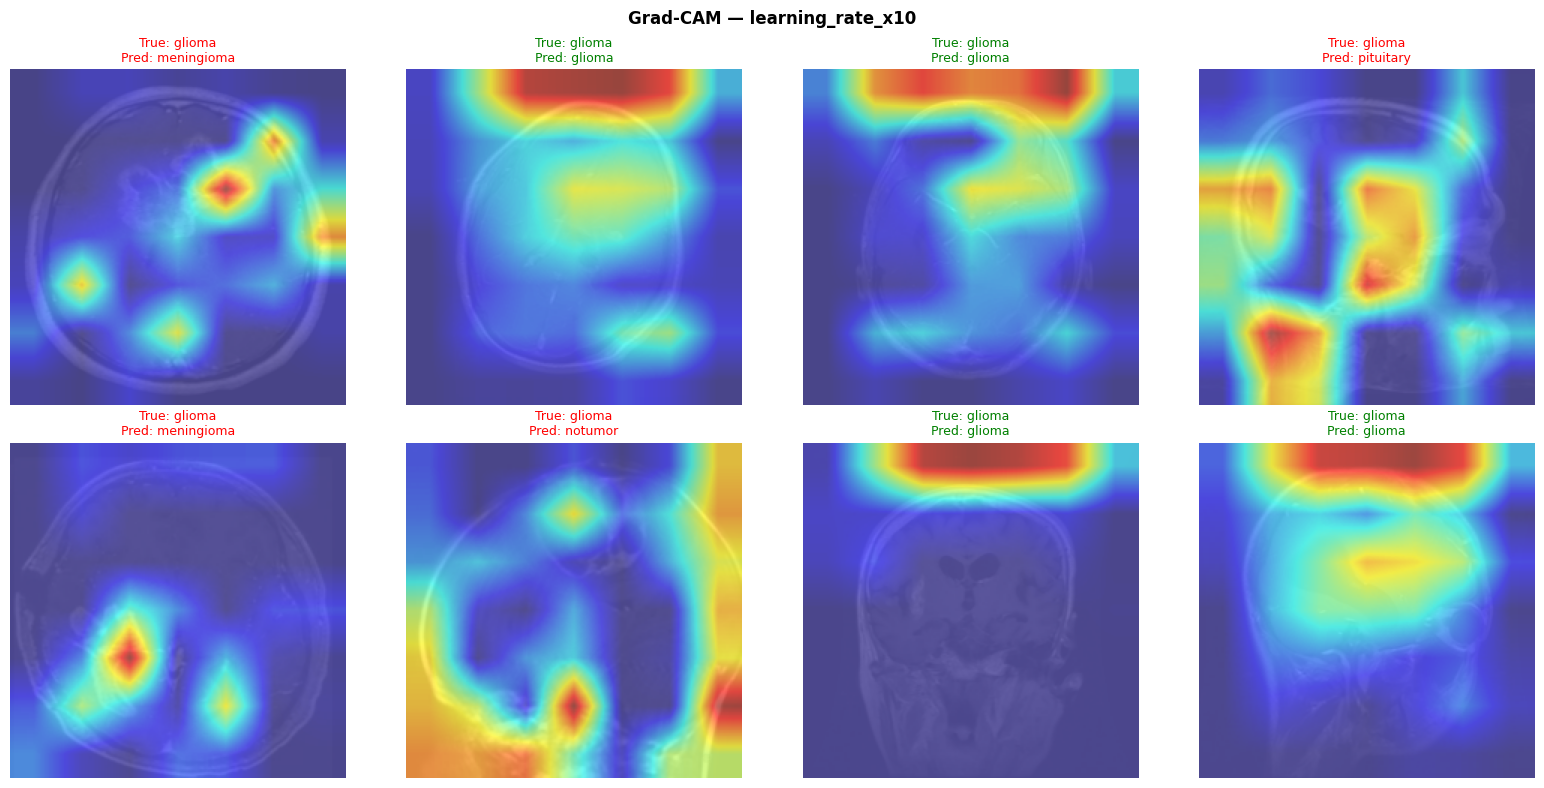


  Experiment : learning_rate_div2
  Classes    : ['glioma', 'meningioma', 'notumor', 'pituitary']  (4)
  Img/class  : all
  LR         : 0.0005   Batch: 32
  Train: 4,900  Val: 700  Test: 1,600  Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Ep [ 1/20] Train 0.9296/0.6153 | Val 0.6374/0.7386 | 205.1s ✅
Ep [ 2/20] Train 0.6390/0.7598 | Val 0.4617/0.8300 | 211.7s ✅
Ep [ 3/20] Train 0.5072/0.8159 | Val 0.5142/0.7971 | 214.3s
Ep [ 4/20] Train 0.4379/0.8402 | Val 0.3808/0.8629 | 214.4s ✅
Ep [ 5/20] Train 0.3544/0.8663 | Val 0.8894/0.8129 | 202.3s
Ep [ 6/20] Train 0.2931/0.8959 | Val 0.2850/0.9043 | 210.8s ✅
Ep [ 7/20] Train 0.2912/0.8957 | Val 0.2943/0.8886 | 214.1s
Ep [ 8/20] Train 0.2445/0.9137 | Val 0.3323/0.9043 | 214.3s
Ep [ 9/20] Train 0.2154/0.9235 | Val 0.1850/0.9243 | 206.3s ✅
Ep [10/20] Train 0.1789/0.9369 | Val 0.1830/0.9371 | 213.5s ✅
Ep [11/20] Train 0.1434/0.9514 | Val 0.1994/0.9386 | 217.7s
Ep [12/20] Train 0.2733/0.9078 | Val 0.2266/0.9114 | 223.6s
Ep [13/20] Tra

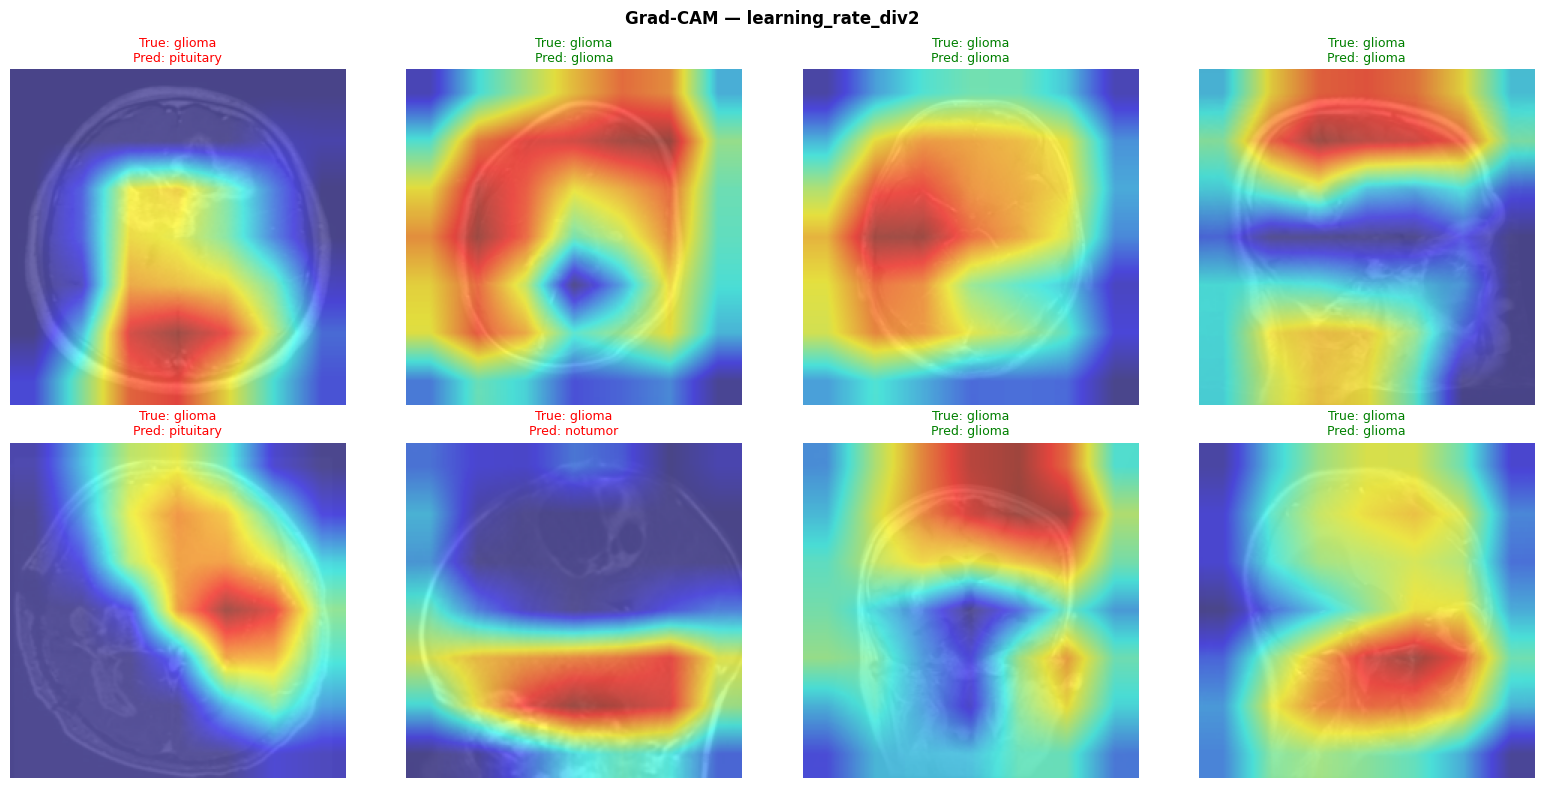


  Experiment : batch_size_100
  Classes    : ['glioma', 'meningioma', 'notumor', 'pituitary']  (4)
  Img/class  : all
  LR         : 0.001   Batch: 100
  Train: 4,900  Val: 700  Test: 1,600  Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Ep [ 1/20] Train 1.0154/0.5520 | Val 1.5040/0.2500 | 1234.1s ✅
Ep [ 2/20] Train 0.6936/0.7235 | Val 1.0902/0.6186 | 997.3s ✅
Ep [ 3/20] Train 0.5859/0.7847 | Val 0.7701/0.7414 | 1012.0s ✅
Ep [ 4/20] Train 0.4669/0.8345 | Val 0.3570/0.8771 | 973.6s ✅
Ep [ 5/20] Train 0.3681/0.8737 | Val 0.3373/0.8771 | 975.7s ✅
Ep [ 6/20] Train 0.3410/0.8729 | Val 0.3783/0.8657 | 40565.7s
Ep [ 7/20] Train 0.3024/0.8916 | Val 0.2351/0.9186 | 1011.7s ✅
Ep [ 8/20] Train 0.2695/0.9035 | Val 0.2227/0.9271 | 1015.7s ✅
Ep [ 9/20] Train 0.2228/0.9202 | Val 0.2111/0.9271 | 1018.5s ✅
Ep [10/20] Train 0.1994/0.9316 | Val 0.2127/0.9371 | 1018.1s
Ep [11/20] Train 0.1666/0.9390 | Val 0.4800/0.8400 | 1004.1s
Ep [12/20] Train 0.1679/0.9404 | Val 0.1738/0.9357 | 995.5s ✅
Ep 

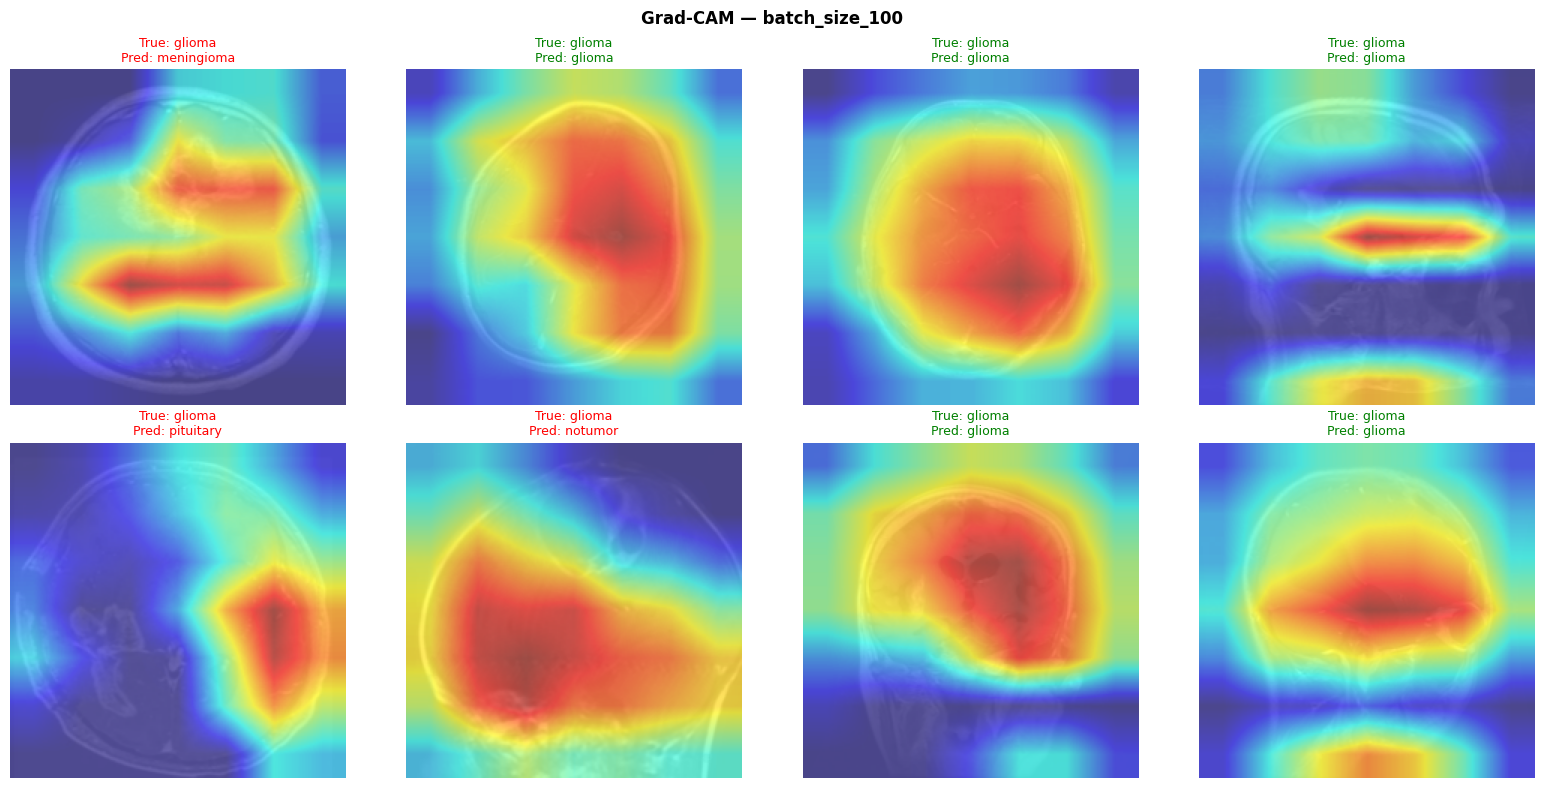


  Experiment : batch_size_15
  Classes    : ['glioma', 'meningioma', 'notumor', 'pituitary']  (4)
  Img/class  : all
  LR         : 0.001   Batch: 15
  Train: 4,900  Val: 700  Test: 1,600  Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Ep [ 1/20] Train 1.0056/0.5731 | Val 0.7131/0.7329 | 181.4s ✅
Ep [ 2/20] Train 0.7201/0.7190 | Val 0.7955/0.7586 | 103.6s
Ep [ 3/20] Train 0.5913/0.7876 | Val 0.5571/0.7971 | 126.6s ✅
Ep [ 4/20] Train 0.4565/0.8390 | Val 0.3367/0.8829 | 139.9s ✅
Ep [ 5/20] Train 0.4210/0.8524 | Val 0.8288/0.7957 | 133.8s
Ep [ 6/20] Train 0.3552/0.8751 | Val 0.7512/0.8700 | 145.9s
Ep [ 7/20] Train 0.3384/0.8812 | Val 0.2288/0.9143 | 130.9s ✅
Ep [ 8/20] Train 0.2809/0.9006 | Val 1.8936/0.8557 | 129.8s
Ep [ 9/20] Train 0.2405/0.9171 | Val 0.3937/0.8814 | 133.8s
Ep [10/20] Train 0.2286/0.9235 | Val 0.3401/0.8857 | 97.3s
Ep [11/20] Train 0.2180/0.9245 | Val 0.2592/0.9129 | 65.4s
Ep [12/20] Train 0.1345/0.9529 | Val 0.1301/0.9529 | 71.4s ✅
Ep [13/20] Train 0.1176/0

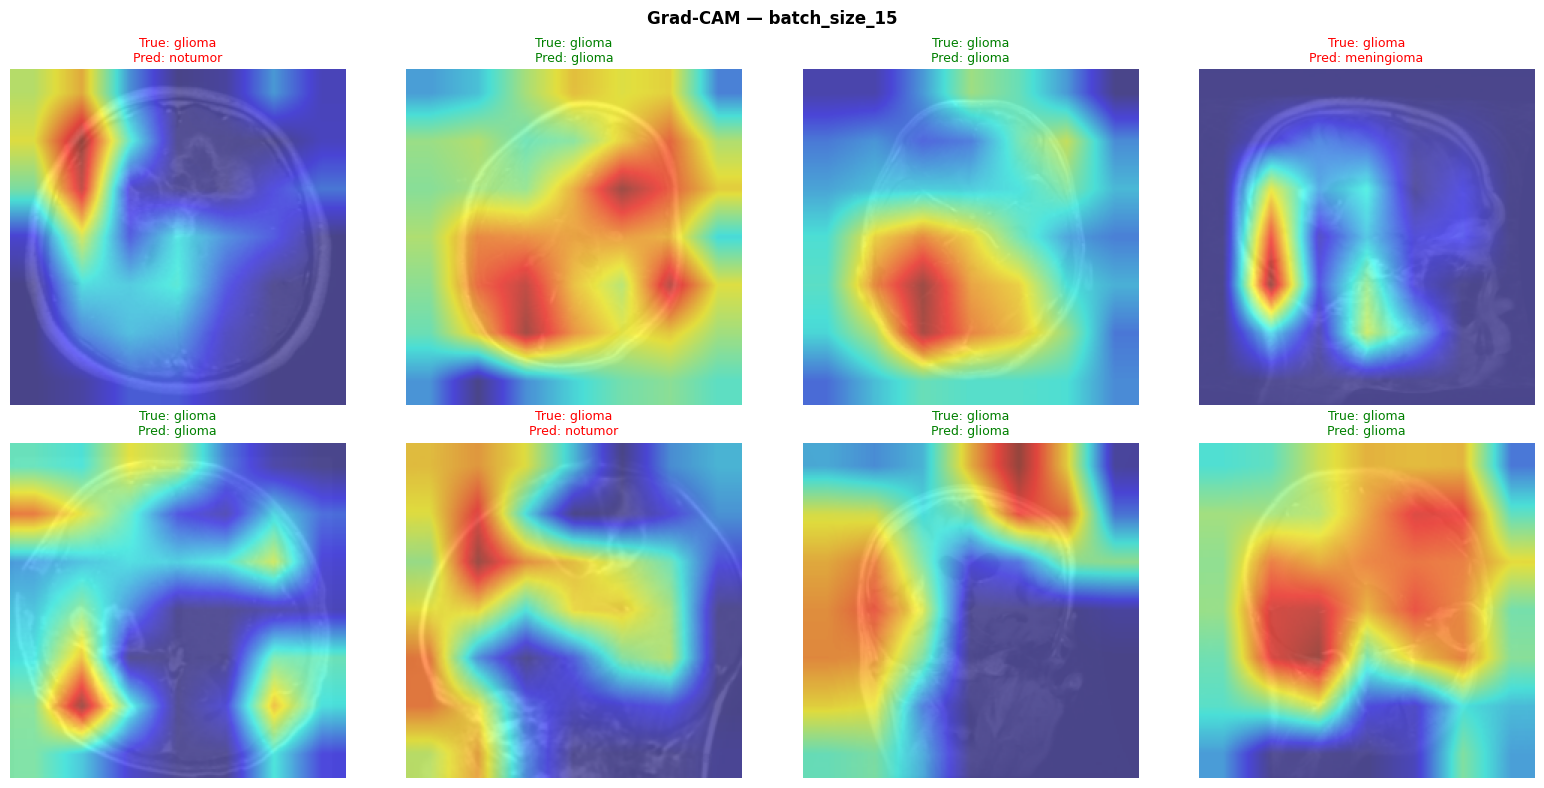


All experiments done!


In [13]:
all_results   = {}
all_histories = {}

for exp in experiments:
    exp_name    = exp['name']
    num_classes = len(exp['classes'])

    print(f'\n{"="*60}')
    print(f'  Experiment : {exp_name}')
    print(f'  Classes    : {exp["classes"]}  ({num_classes})')
    print(f'  Img/class  : {exp["images_per_class"] or "all"}')
    print(f'  LR         : {exp["learning_rate"]}   Batch: {exp["batch_size"]}')
    print(f'{"="*60}')

    train_loader, val_loader, test_loader, class_names = build_exp_loaders(exp)

    cfg = {
        'num_classes':   num_classes,
        'class_names':   class_names,
        'train_loader':  train_loader,
        'val_loader':    val_loader,
        'test_loader':   test_loader,
    }

    model = build_efficientNet_b2(num_classes)
    ckpt  = OUTPUT_DIR / f'efficientNet_b2_ds2_{exp_name}_best.pth'
    model, history = train_model(model, cfg, ckpt, learning_rate=exp['learning_rate'])

    #  Overfitting gap per epoch 
    print('\n── Overfitting Gap (Train Acc - Val Acc) per epoch ──')
    print(f'  {"Epoch":<8} {"Train Acc":>10} {"Val Acc":>10} {"Gap %":>8} {"Status":>12}')
    print(f'  {"-"*50}')
    for ep_idx, (tr, vl) in enumerate(zip(history['train_acc'], history['val_acc']), start=1):
        gap    = tr - vl
        status = '⚠ Overfit' if gap > 0.15 else ('⚠ Underfit' if tr < 0.60 and vl < 0.60 else '✓ OK')
        print(f'  {ep_idx:<8} {tr*100:>9.1f}% {vl*100:>9.1f}% {gap*100:>7.1f}% {status:>12}')
    print(f'\n  Final gap: {(history["train_acc"][-1] - history["val_acc"][-1])*100:.1f}%')

    #  Test evaluation 
    print('\n── Test Results ──')
    results = full_evaluation(model, cfg['test_loader'], num_classes, class_names)
    all_results[exp_name]   = results
    all_histories[exp_name] = history

    #  Val vs Test generalisation check 
    best_val_acc = max(history['val_acc'])
    print(f'\n── Generalisation Check ──')
    print(f'  Best Val Accuracy  : {best_val_acc*100:.2f}%')
    print(f'  Test Accuracy      : {results["acc"]*100:.2f}%')
    gap_vt = (best_val_acc - results["acc"]) * 100
    print(f'  Gap                : {gap_vt:.2f}%')
    if abs(gap_vt) > 5:
        print('  ⚠ Large gap between val and test — model may not generalise well')
    else:
        print('  ✓ Val and test accuracy are close — good generalisation')

    #  Grad-CAM 
    plot_grad_cam(model, cfg['test_loader'], class_names, exp_name,
                  OUTPUT_DIR / f'efficientNet_b2_ds2_{exp_name}_gradcam.png')

    del model; torch.cuda.empty_cache()

print('\nAll experiments done!')


── Plots: full_dataset ──


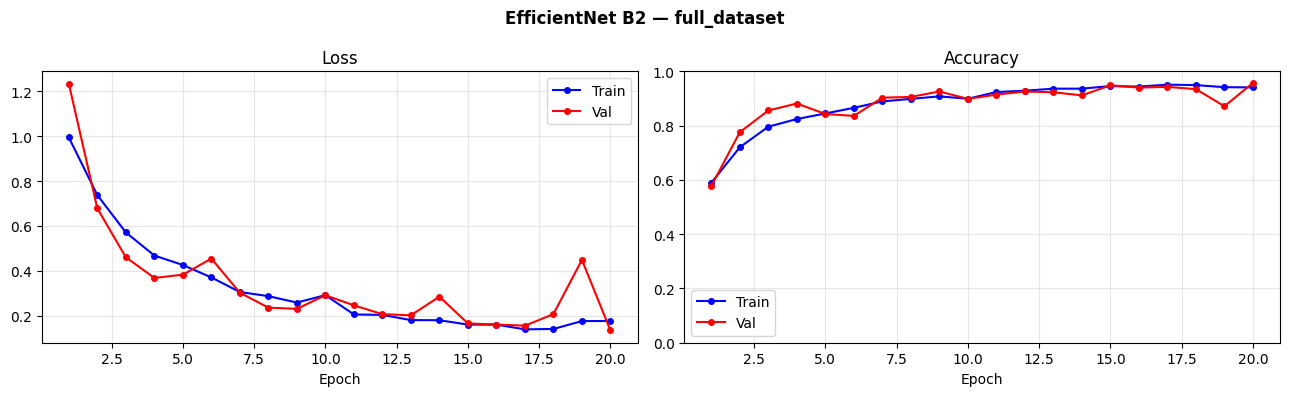

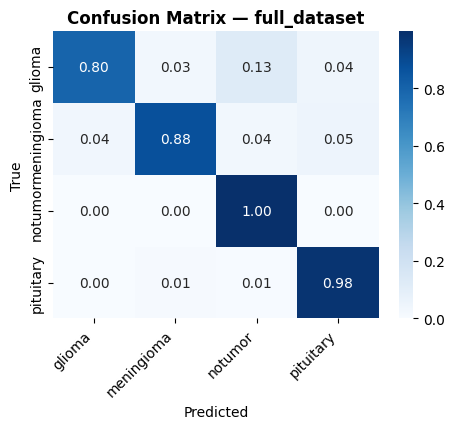

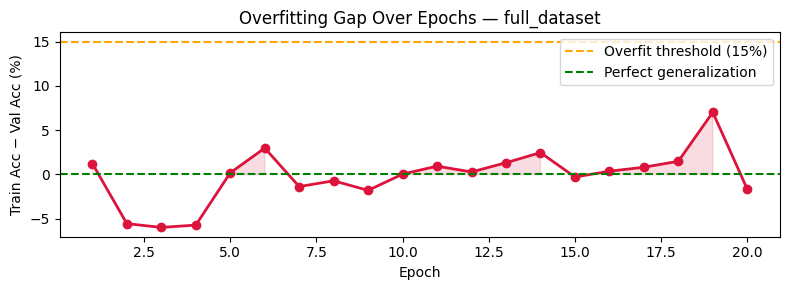


── Plots: reduced_classes ──


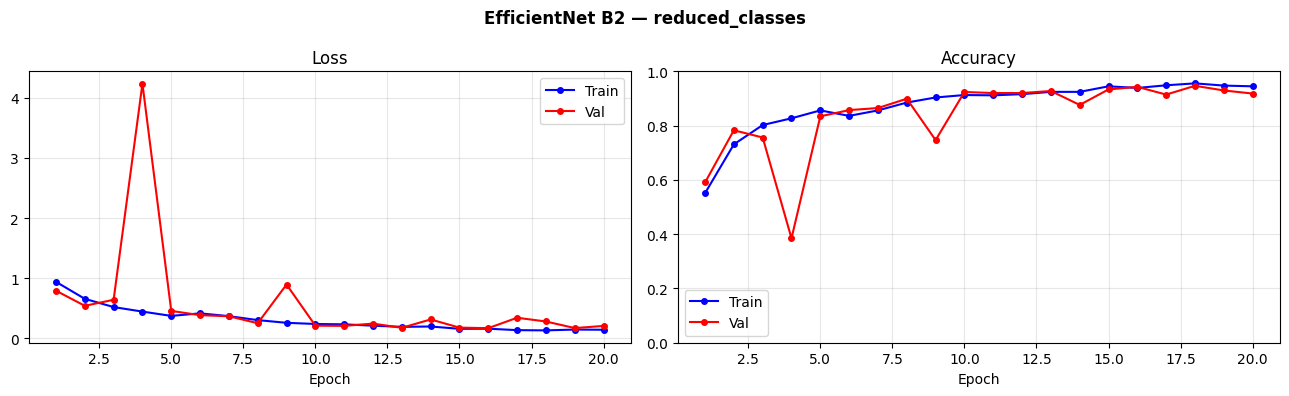

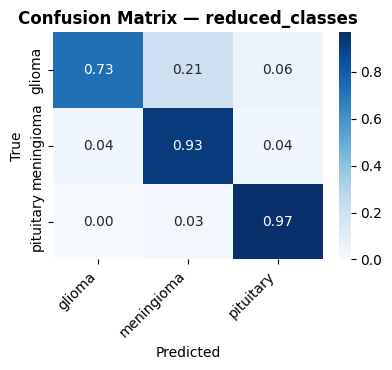

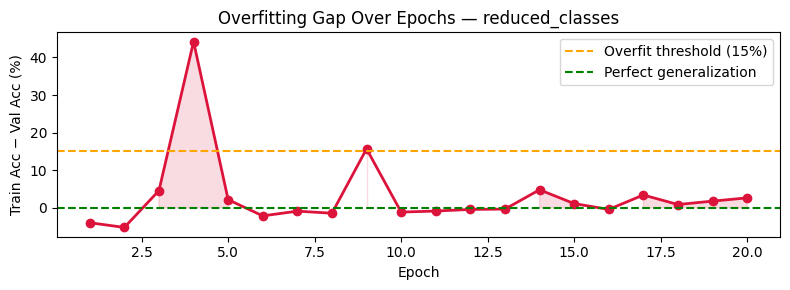


── Plots: limited_images ──


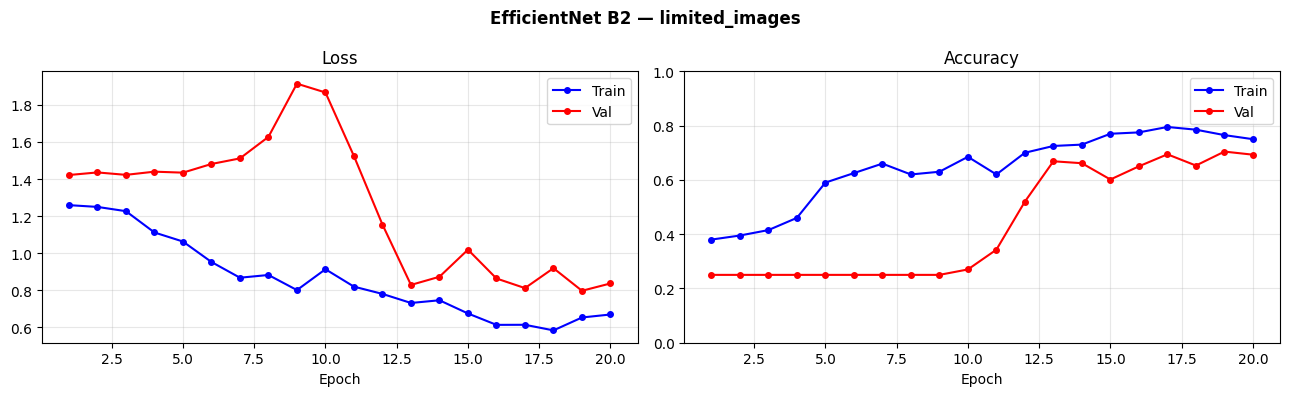

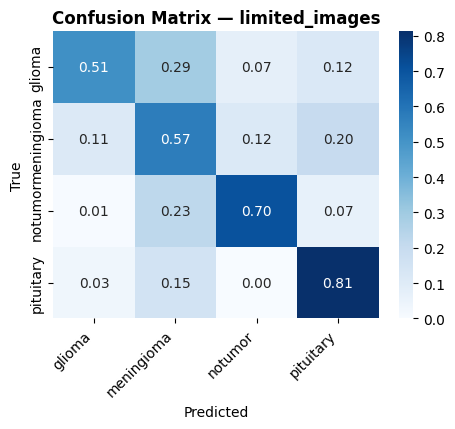

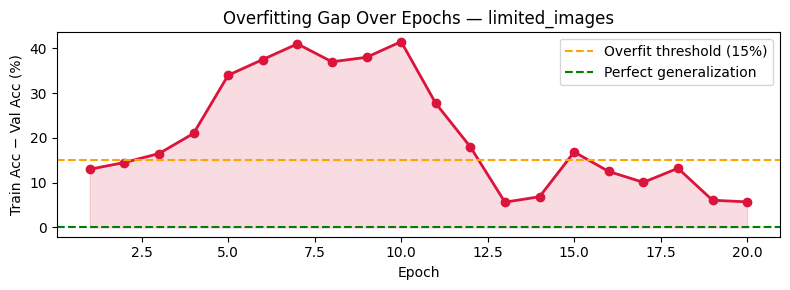


── Plots: very_limited_images ──


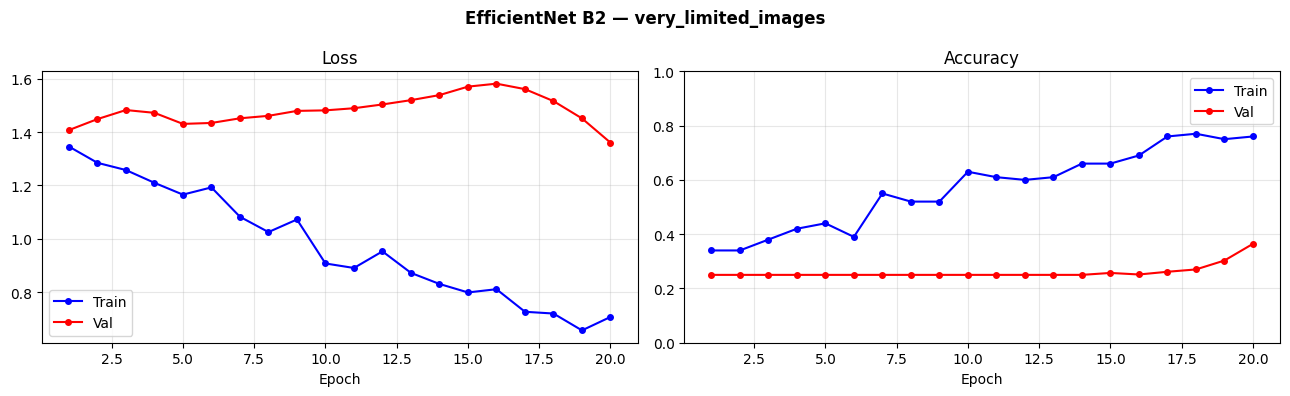

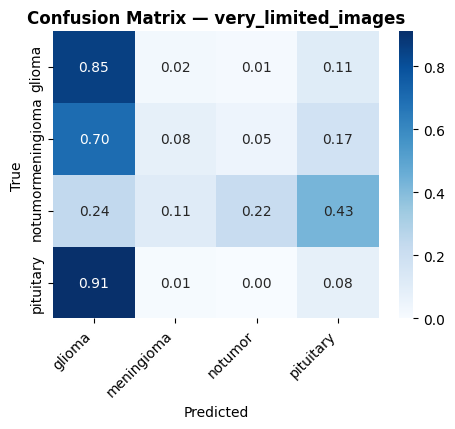

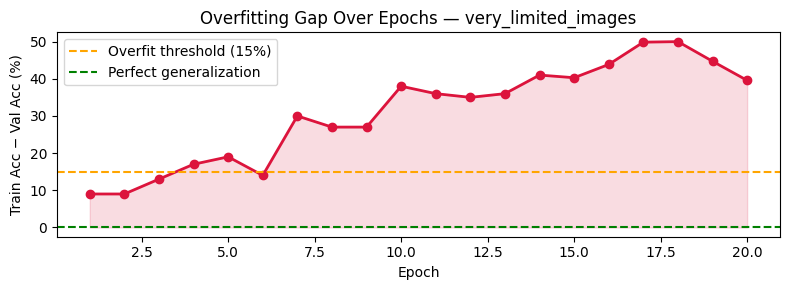


── Plots: learning_rate_x10 ──


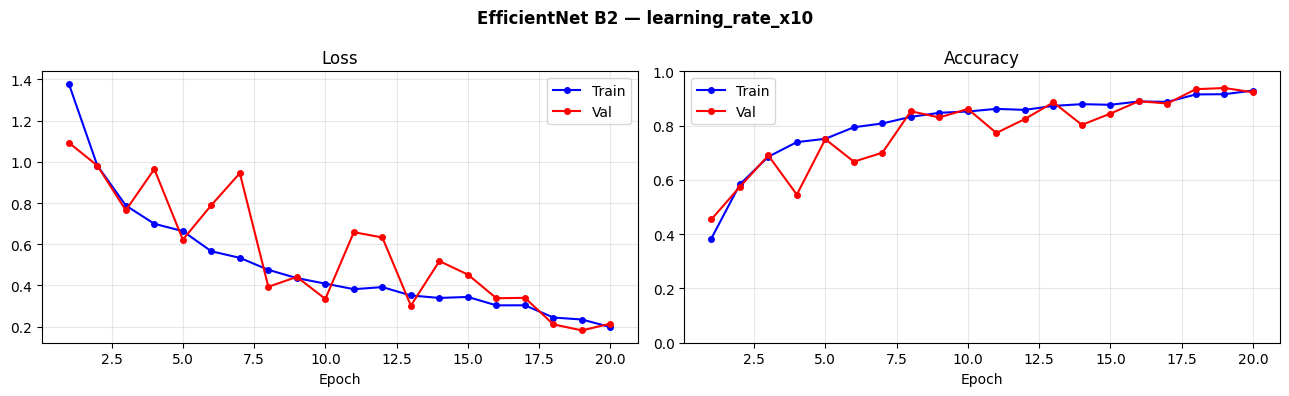

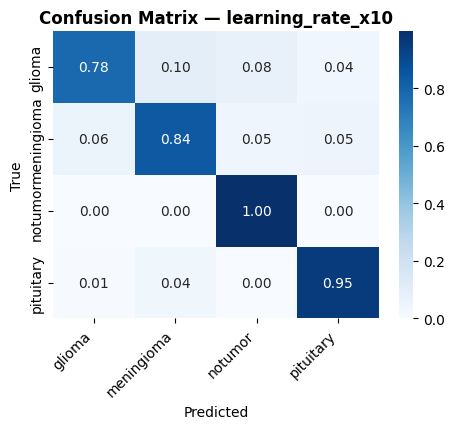

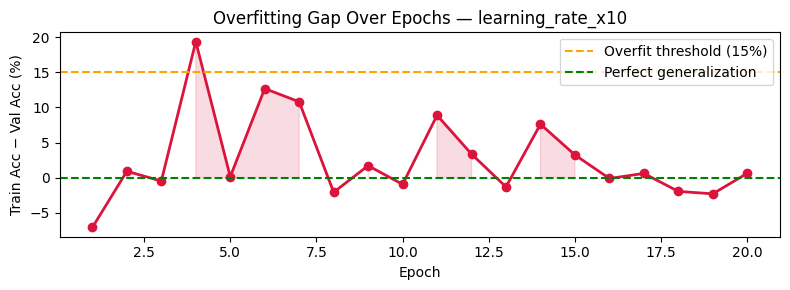


── Plots: learning_rate_div2 ──


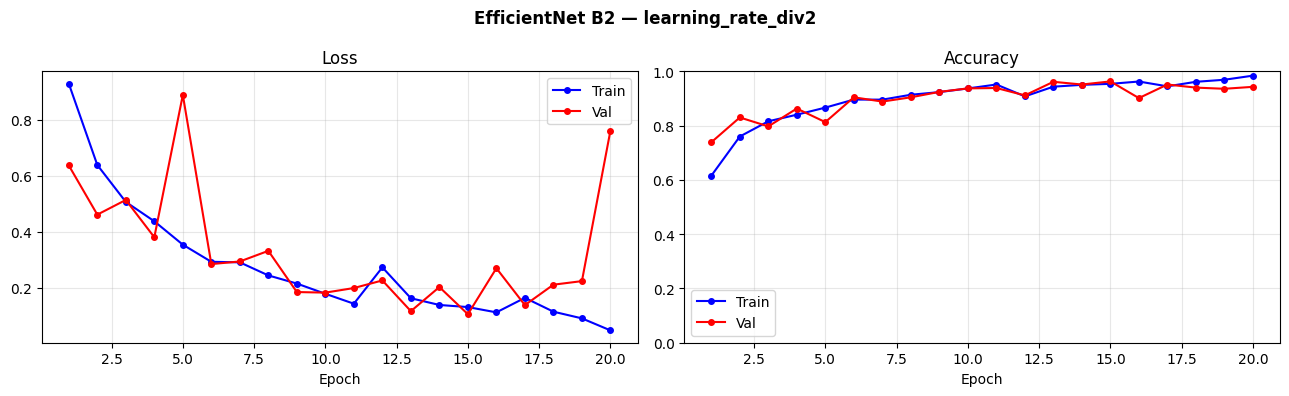

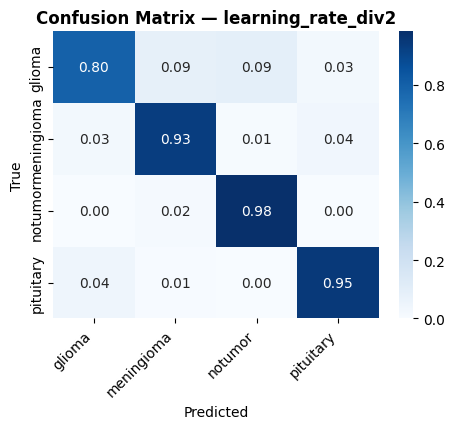

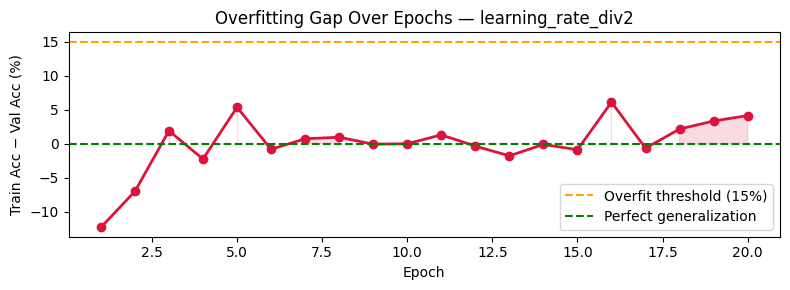


── Plots: batch_size_100 ──


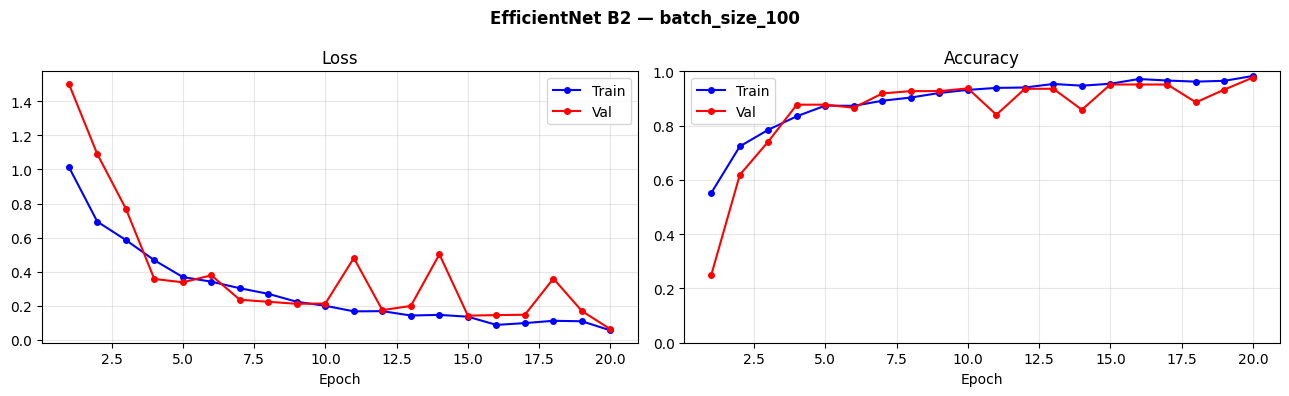

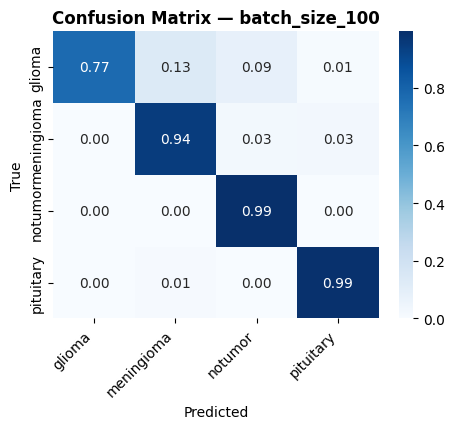

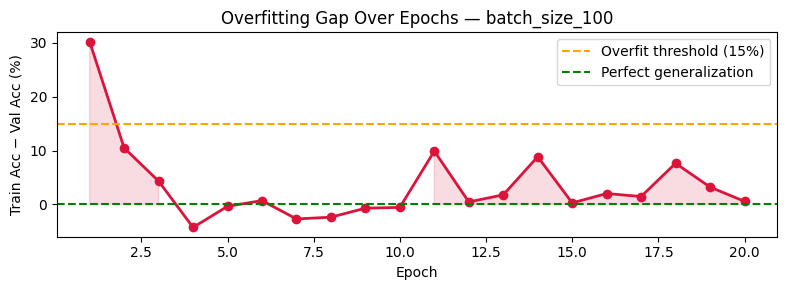


── Plots: batch_size_15 ──


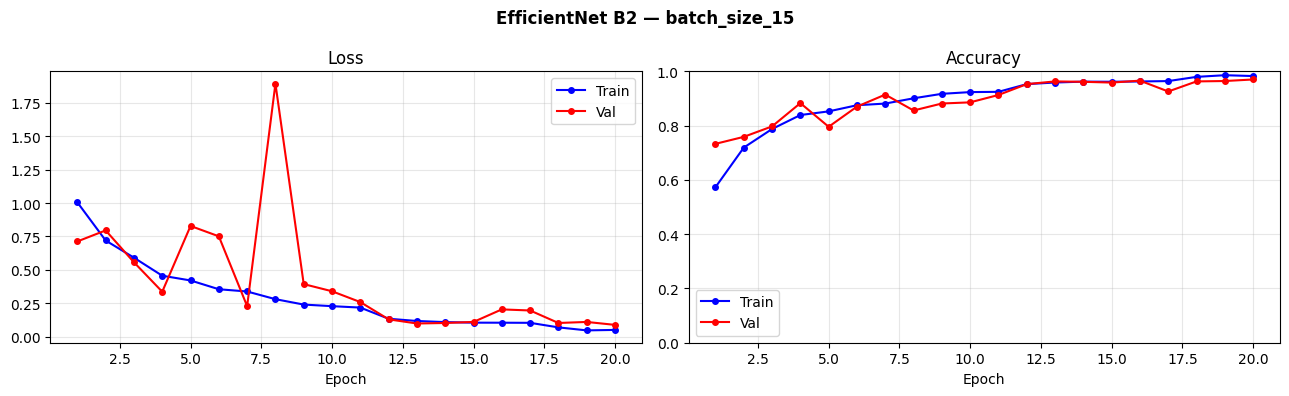

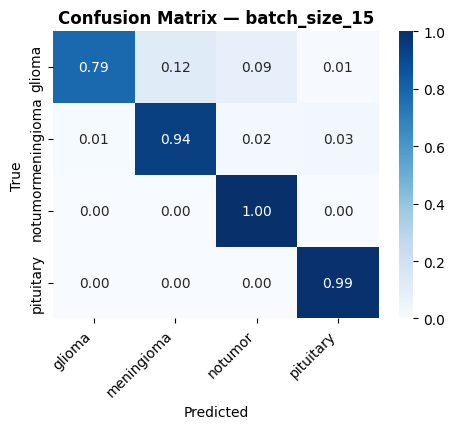

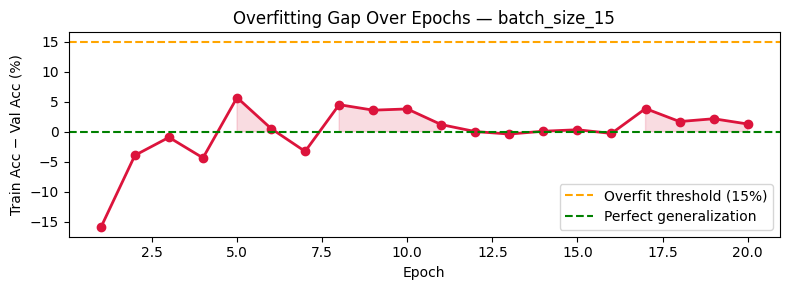


All plots saved!


In [14]:
for exp in experiments:
    exp_name = exp['name']
    if exp_name not in all_results:
        continue

    history     = all_histories[exp_name]
    results     = all_results[exp_name]
    class_names = exp['classes']

    print(f'\n── Plots: {exp_name} ──')
    plot_curves(history, exp_name,
                OUTPUT_DIR / f'efficientNet_b2_ds2_{exp_name}_curves.png')
    plot_confusion_matrix(results, class_names, exp_name,
                OUTPUT_DIR / f'efficientNet_b2_ds2_{exp_name}_confusion.png')

    # Overfitting gap plot
    epochs = range(1, len(history['train_acc']) + 1)
    gaps   = [(tr - vl) * 100 for tr, vl in zip(history['train_acc'], history['val_acc'])]
    plt.figure(figsize=(8, 3))
    plt.plot(epochs, gaps, marker='o', color='crimson', linewidth=2)
    plt.axhline(y=15, color='orange', linestyle='--', label='Overfit threshold (15%)')
    plt.axhline(y=0,  color='green',  linestyle='--', label='Perfect generalization')
    plt.fill_between(epochs, gaps, 0, where=[g > 0 for g in gaps], alpha=0.15, color='crimson')
    plt.title(f'Overfitting Gap Over Epochs — {exp_name}')
    plt.xlabel('Epoch'); plt.ylabel('Train Acc − Val Acc (%)')
    plt.legend(); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'efficientNet_b2_ds2_{exp_name}_gap.png', dpi=150)
    plt.show()

print('\nAll plots saved!')

## 8. Results Summary

In [15]:
import json

exp_lookup = {exp['name']: exp for exp in experiments}

rows = [
    {
        'Experiment':       exp_name,
        'Model':            'EfficientNet B2 (untrained)',
        'Classes':          len(exp_lookup[exp_name]['classes']),
        'Class_Names':      ', '.join(exp_lookup[exp_name]['classes']),
        'Images_per_class': exp_lookup[exp_name]['images_per_class'] or 'all',
        'Batch_Size':       exp_lookup[exp_name]['batch_size'],
        'Epochs':           NUM_EPOCHS,
        'Learning_Rate':    exp_lookup[exp_name]['learning_rate'],
        'Weight_Decay':     WEIGHT_DECAY,
        'Image_Size':       IMG_SIZE,
        'Accuracy':         f"{r['acc']:.4f}",
        'Precision':        f"{r['prec']:.4f}",
        'Recall':           f"{r['rec']:.4f}",
        'F1-Score':         f"{r['f1']:.4f}",
    }
    for exp_name, r in all_results.items()
]

df = pd.DataFrame(rows)
print(df.to_string())
df.to_csv(OUTPUT_DIR / 'efficientnet_b2_ds2_ablation_results.csv', index=False)
print(f'\nSaved to {OUTPUT_DIR}/efficientnet_b2_ds2_ablation_results.csv')

# Save per-experiment training history
for exp_name, history in all_histories.items():
    history_path = OUTPUT_DIR / f'efficientNet_b2_ds2_{exp_name}_history.json'
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)
    print(f'Saved history: {history_path.name}')

            Experiment                        Model  Classes                             Class_Names Images_per_class  Batch_Size  Epochs  Learning_Rate  Weight_Decay  Image_Size Accuracy Precision  Recall F1-Score
0         full_dataset  EfficientNet B2 (untrained)        4  glioma, meningioma, notumor, pituitary              all          32      20         0.0010        0.0001         224   0.9119    0.9168  0.9119   0.9105
1      reduced_classes  EfficientNet B2 (untrained)        3           glioma, meningioma, pituitary              all          32      20         0.0010        0.0001         224   0.8750    0.8846  0.8750   0.8731
2       limited_images  EfficientNet B2 (untrained)        4  glioma, meningioma, notumor, pituitary               50          32      20         0.0010        0.0001         224   0.6506    0.6749  0.6506   0.6525
3  very_limited_images  EfficientNet B2 (untrained)        4  glioma, meningioma, notumor, pituitary               25          32      20   